In [1]:
# Parameters
summary_config = {"run_run_comparison": False, "run_RTP_summary": False, "run_validation": True, "run_network_validation": True, "summary_list": {"RTP-summary-notebook": ["RTP_index", "RTP_congestion", "RTP_topsheet", "RTP_MIC", "RTP_person", "RTP_household", "RTP_access", "RTP_costs", "RTP_walk_bike", "RTP_emissions", "RTP_mode_share", "RTP_freight", "RTP_transit"], "activitysim-validation-notebook": ["work_from_home", "auto_ownership", "telecommute_frequency", "free_parking", "cdap", "intermediate_stop_frequency", "trip_purpose", "trip_destination_choice", "school_location", "work_location", "mandatory_tour_frequency", "mandatory_tour_scheduling", "non_mandatory_tour_frequency", "non_mandatory_tour_destination_choice", "non_mandatory_tour_scheduling", "joint_tour_frequency", "joint_tour_composition", "atwork_subtours_frequency", "atwork_subtours_destination_choice", "atwork_subtours_scheduling", "atwork_subtour_mode", "tour_mode_choice", "trip_mode_choice"], "daysim-validation-notebook": ["all_tour_mode", "all_trip_mode", "auto_ownership", "day_pattern", "escort_tour_mode", "escort_trip_mode", "households", "intermediate_stop_generation", "other_home_based_tour_mode", "other_home_based_trip_mode", "persons", "school_location", "school_tour_mode", "school_trip_mode", "telecommute", "time_choice", "tours", "tour_destination", "transit_pass_ownership", "trips", "trip_destination", "workbased_subtour_generation", "workbased_subtour_mode", "work_location", "work_tour_mode", "work_trip_mode"], "network-validation-notebook": ["JBLM", "supplementals", "transit_validation", "traffic_validation", "bike_validation", "link_analysis"], "run-comparison-notebook": ["topsheet", "population", "parking", "vmt", "transit"]}, "p_output_dir": "outputs/summary", "output_folder": "outputs", "survey_folder": "inputs/base_year/survey", "uncloned_folder": "uncloned", "sc_run_name": "current run", "sc_run_path": "../../../../", "survey_directories": {"survey": "../../../../inputs/base_year/survey"}, "comparison_runs_list": {"2050 new transit, old network": "\\\\modelstation3\\c$\\Workspace\\sc_new_2050_transit\\soundcast", "2050 urbansim": "\\\\modelstation2\\c$\\Workspace\\sc_2050_urbansim2_07_30_25"}, "county_map": {"33": "King", "35": "Kitsap", "53": "Pierce", "61": "Snohomish"}, "uc_list": ["@sov_inc1", "@sov_inc2", "@sov_inc3", "@hov2_inc1", "@hov2_inc2", "@hov2_inc3", "@hov3_inc1", "@hov3_inc2", "@hov3_inc3", "@av_sov_inc1", "@av_sov_inc2", "@av_sov_inc3", "@av_hov2_inc1", "@av_hov2_inc2", "@av_hov2_inc3", "@av_hov3_inc1", "@av_hov3_inc2", "@av_hov3_inc3", "@tnc_inc1", "@tnc_inc2", "@tnc_inc3", "@mveh", "@hveh", "@bveh"], "agency_lookup": {"1": "King County Metro", "2": "Pierce Transit", "3": "Community Transit", "4": "Kitsap Transit", "5": "Washington Ferries", "6": "Sound Transit", "7": "Everett Transit"}, "emissions_scenario": "standard", "tot_veh_model_base_year": 3185281, "speed_bins": [-999999.0, 2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5, 67.5, 72.5, 999999.0], "fac_type_lookup": {"0": 0, "1": 4, "2": 4, "3": 5, "4": 5, "5": 5, "6": 3, "7": 5, "8": 0}, "tod_lookup": {"5to6": 5, "6to7": 6, "7to8": 7, "8to9": 8, "9to10": 9, "10to14": 10, "14to15": 14, "15to16": 15, "16to17": 16, "17to18": 17, "18to20": 18, "20to5": 20}, "summer_list": [87], "special_route_lookup": {"1671": "A-Line Rapid Ride", "1672": "B-Line Rapid Ride", "1673": "C-Line Rapid Ride", "1674": "D-Line Rapid Ride", "1675": "E-Line Rapid Ride", "1677": "H-Line Rapid Ride", "4950": "Central Link", "6995": "Tacoma Link", "6998": "Sounder South", "6999": "Sounder North", "3701": "Swift Blue Line", "3702": "Swift Green Line"}}
input_config = {"debug_skims_and_paths": False, "model_year": "2023", "base_year": "2023", "landuse_inputs": "23_on_23_v3", "network_inputs": "base_year_2023_final", "db_name": "soundcast_inputs_2023.db", "soundcast_inputs_dir": "R:/e2projects_two/SoundCast/Inputs/rtp_2026_2050", "abm_model": "daysim", "run_accessibility_calcs": False, "run_setup_emme_project_folders": False, "run_setup_emme_bank_folders": False, "run_copy_scenario_inputs": False, "run_import_networks": False, "run_skims_and_paths_free_flow": False, "run_skims_and_paths": False, "run_truck_model": False, "run_supplemental_trips": False, "run_daysim": False, "run_summaries": True, "include_av": False, "include_tnc": True, "tnc_av": False, "include_tnc_to_transit": False, "include_knr_to_transit": False, "include_delivery": False, "include_telecommute": True, "run_integrated": False, "should_build_shadow_price": False, "delete_banks": False, "include_tnc_emissions": True, "add_distance_pricing": False, "distance_rate_dict": {"am": 13.5, "md": 8.5, "pm": 13.5, "ev": 8.5, "ni": 8.5}}


In [2]:

import os
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import h5py
import toml
from pathlib import Path



root_dir = os.path.abspath(os.path.join('../../../..'))
config_dir = os.path.join(root_dir, 'configuration')
valid_config = toml.load(os.path.join(config_dir, 'validation_configuration.toml'))
input_config = toml.load(os.path.join(config_dir, 'input_configuration.toml'))
config = toml.load(os.path.join(config_dir, 'summary_configuration.toml'))
# network_config = toml.load(os.path.join(config_dir, 'network_configuration.toml'))

# JBLM
The military base Joint Baise Lewis-McChord (JBLM) is treated uniquely in the model.



In [3]:
# Military work trips are added as ODs in ixxi_work_trips.h5

def get_external_trips(myh5, NUM_ZONES):

    # Read trip table and get indeces
    # Read table data for each mode and combine into single matrix
    
    # Note: we are assuming ordinal indexing for externals, do not use these to select zone IDs outside of internal zones

    trips = np.zeros((NUM_ZONES, NUM_ZONES), dtype=np.float64)
    for mode in ['sov','hov2','hov3']:
        trips += myh5[mode][:]
    df = pd.DataFrame(
        trips, 
        columns=range(1,NUM_ZONES+1), 
        index=range(1,NUM_ZONES+1)
        )
    
    return df

In [4]:

conn = create_engine(f'sqlite:///{root_dir}/inputs/db/'+input_config['db_name'])
work_h5_files = sorted(Path(root_dir, 'outputs', 'supplemental').glob('external_work_*.h5'))
if not work_h5_files:
    raise FileNotFoundError('No external_work_*.h5 files found in outputs/supplemental')
myh5 = h5py.File(work_h5_files[0], 'r')
NUM_ZONES = len(myh5['sov'][:])
jblm_taz_list = pd.read_sql_query("SELECT * FROM psrc_zones where jblm=1", conn)['taz'].to_list()

results_df = pd.DataFrame(
    np.zeros([NUM_ZONES, NUM_ZONES]),
    columns=range(1,NUM_ZONES+1), 
    index=range(1,NUM_ZONES+1)
    )
for work_h5 in work_h5_files:
    myh5 = h5py.File(work_h5, 'r')
    df = get_external_trips(myh5, NUM_ZONES)
    results_df = results_df + df

# create_ixxi_work_trips.py
### Vehicle trips to/from JBLM zones by origin/destination 

In [5]:

df = pd.DataFrame(results_df[jblm_taz_list].sum(), columns=['trips_to_jblm'])
df_from = pd.DataFrame(results_df.loc[jblm_taz_list].sum(axis=1), columns=['trips_from_jblm'])
df = df.merge(df_from, left_index=True, right_index=True, how='outer')

# Display with commas and as integer
df = df.sort_values(by='trips_from_jblm', ascending=False)
df['trips_total'] = df['trips_to_jblm'] + df['trips_from_jblm']
df.loc['Total'] = df.sum(numeric_only=True)
for col in df.columns:
    df[col] = df[col].apply(lambda x: f"{int(x):,}")

df


,trips_to_jblm,trips_from_jblm,trips_total
3351,"16,557","16,557","33,114"
3070,"10,975","10,975","21,950"
3353,"7,302","7,302","14,604"
3355,"7,162","7,162","14,325"
3349,"6,091","6,091","12,182"
3350,"2,944","2,944","5,889"
3354,"2,735","2,735","5,470"
3352,"1,561","1,561","3,123"
3346,"1,180","1,180","2,361"
3356,984,984,"1,969"


# Daysim Vehicle Trips to/from JBLM

In [6]:
trips_df = pd.read_csv(f"{root_dir}/outputs/daysim/_trip.tsv",
                    sep='\t')

In [7]:
from_trips = trips_df[(trips_df['otaz'].isin(jblm_taz_list)) & (trips_df['dorp']==1) & (trips_df['mode'].isin([3,4,5]))]
to_trips = trips_df[(trips_df['dtaz'].isin(jblm_taz_list)) & (trips_df['dorp']==1) & (trips_df['mode'].isin([3,4,5]))]
print(f"Total Daysim trips from JBLM zones: {from_trips['trexpfac'].sum()}")
print(f"Total Daysim trips to JBLM zones: {to_trips['trexpfac'].sum()}")

Total Daysim trips from JBLM zones: 10368
Total Daysim trips to JBLM zones: 10372


#### Daysim trips from JBLM by purpose
Since employment is removed from JBLM, we expect Daysim to not predict work trips (opurp==1) inside JBLM

In [8]:
# 
pd.DataFrame([from_trips['opurp'].value_counts(),
              to_trips['dpurp'].value_counts()]).T.fillna(0).astype(int).rename(
    columns={'count': 'from_JBLM', 'count': 'to_JBLM'}
              )

,to_JBLM,to_JBLM
0,9677,9685
3,370,362
7,207,210
4,67,67
6,40,40
2,6,7
5,1,1


## Daysim Results for JBLM Residents

In [9]:
# Residents in JBLM zones
hh_df = pd.read_csv(f"{root_dir}/outputs/daysim/_household.tsv",
                    sep='\t')
person_df = pd.read_csv(f"{root_dir}/outputs/daysim/_person.tsv",
                    sep='\t')
person_df = person_df.merge(hh_df[['hhtaz','hhno']], on='hhno', how='left')
jblm_person_df = person_df[person_df['hhtaz'].isin(jblm_taz_list)].copy()

print(f"Total Daysim persons in JBLM zones: {jblm_person_df['pno'].nunique()}")

Total Daysim persons in JBLM zones: 8


### Persons with Job Locations in JBLM Zones
Should be minimal because employment in JBLM zones is zeroed out in create_ixxi_work_trips.py 

In [10]:
jblm_person_df = person_df[person_df['hhtaz'].isin(jblm_taz_list)].copy()
jblm_person_df['job_in_jblm'] = "Not in JBLM"
jblm_person_df.loc[jblm_person_df['pwtaz'].isin(jblm_taz_list), 'job_in_jblm']  = "In JBLM"

pd.DataFrame(jblm_person_df['job_in_jblm'].value_counts())

,count
job_in_jblm,
Not in JBLM,16319
In JBLM,310


### Age Distribution
Of synthetic population within JBLM zones

Text(0.5, 1.0, 'Distribution of Age in JBLM Zones')

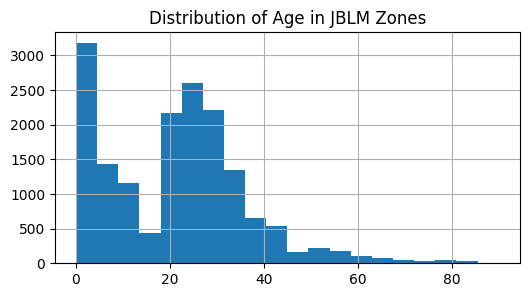

In [11]:
# Plot distribution of pagey 
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
jblm_person_df['pagey'].hist(bins=20)
plt.title('Distribution of Age in JBLM Zones')

#### Daysim IXXI File

This file in generated in create_ixxi_work_trips.py and specifies what share of each zone to exclude from DaySim Work Location model

Within JBLM area, Jobs_XIFrac should be 1 because we are using the exogenous data for work flows in these zones
If Jobs_XIFrac == 1 then Daysim will not send workers to jobs in these zones

Worker_IXFrac is not equal to 1 because workers in the synthetic population for these areas 
may have jobs outside the base area (family members of enlisted)


In [12]:
# Load ixxi fractions file and set column names

df_ixxi = pd.read_csv(f"{root_dir}/outputs/landuse/psrc_worker_ixxifractions.dat", sep='\t', header=None)
df_ixxi.columns = ['taz', 'Worker_IXFrac', 'Jobs_XIFrac']
df_ixxi[df_ixxi['taz'].isin(jblm_taz_list)]

,taz,Worker_IXFrac,Jobs_XIFrac
3060,3061,0.011,1.0
3069,3070,1.000,1.0
3345,3346,0.000,1.0
3347,3348,0.010,1.0
3348,3349,0.006,1.0
3349,3350,0.083,1.0
3350,3351,1.000,1.0
3351,3352,0.024,1.0
3352,3353,0.965,1.0
3353,3354,0.000,1.0


# Parcels Jobs

In [13]:
df_parcel_input = pd.read_csv(f"{root_dir}/inputs/scenario/landuse/parcels_urbansim.txt", sep=' ')
df_parcel_output = pd.read_csv(f"{root_dir}/outputs/landuse/parcels_urbansim.txt", sep=' ')

parcels_military = pd.read_sql(
        "SELECT * FROM enlisted_personnel WHERE year=="
        + input_config["model_year"],
        con=conn,
    )

In [14]:
parcels_military = parcels_military.groupby('Zone').sum().reset_index()
parcels_military = parcels_military[['Zone', 'military_jobs']]
parcels_military.rename(columns={'military_jobs': 'military_jobs_target'}, inplace=True)

Compare Military Jobs by Zone before create_ixxi_work_trips.py and afterwards

JBLM Zones should have 0 total employment in output file

In [15]:
df_before = df_parcel_input[df_parcel_input['taz_p'].isin(parcels_military.Zone)].groupby('taz_p')['emptot_p'].sum().reset_index().sort_values(by='emptot_p', ascending=False)
df_after = df_parcel_output[df_parcel_output['taz_p'].isin(parcels_military.Zone)].groupby('taz_p')['emptot_p'].sum().reset_index().sort_values(by='emptot_p', ascending=False)

df = df_before.merge(df_after, left_on='taz_p', right_on='taz_p', how='outer')
df = df.rename(columns={'taz_p': 'taz', 'emptot_p_x': 'emptot_p_input', 'emptot_p_y': 'emptot_p_output'})

df = df.merge(parcels_military, left_on='taz', right_on='Zone', how='outer')
df.drop(columns=['Zone'], inplace=True)

# set index to taz
df = df.set_index('taz')

df_out = df.copy()
df_out.loc['Total'] = df.sum(numeric_only=True)
# # Show results with commas and as integer
# for col in df.columns:
#     df[col] = df[col].apply(lambda x: f"{int(x):,}")
pd.options.display.float_format = '{:0,.0f}'.format

# Show JBLM Zones
df_out[df_out.index.isin(jblm_taz_list)][['emptot_p_input','emptot_p_output']].astype('float')


,emptot_p_input,emptot_p_output
taz,,
3061,167,0
3070,"2,612",0
3348,"1,176",0
3349,540,0
3350,183,0
3351,135,0
3353,304,0
3355,"1,319",0


Other military zones should have emptot_p equal to the target number of military jobs to be added. 
Note that the total military_jobs_target should be higher than military_jobs_added because we do not add JBLM jobs

In [16]:
_df = df[~df.index.isin(jblm_taz_list)].copy()
_df['military_jobs_added'] = _df['emptot_p_output'].astype('int') - _df['emptot_p_input'].astype('int')
_df.loc['Total'] = _df.sum(numeric_only=True)
_df[['emptot_p_input','emptot_p_output','military_jobs_added','military_jobs_target']]


,emptot_p_input,emptot_p_output,military_jobs_added,military_jobs_target
taz,,,,
105,1535,1610,75,75
331,364,568,204,204
351,1185,1485,300,300
2255,976,5680,4704,4704
3496,896,2226,1330,1330
3508,1759,1816,57,57
3518,3034,4750,1716,1716
3626,14893,19677,4784,4784
Total,24642,37812,13170,13170


### Non-Work

Trip Generation

In [17]:
# Productions from external zones
df = pd.read_csv(f"{root_dir}/outputs/supplemental/7_balance_trip_ends.csv")
prods = int(df.loc[df['taz'] >= 3733, 'hsppro'].sum())
print(f"Total productions from external zones: {prods:,}")


Total productions from external zones: 78,411


In [18]:
# Trip Generation
# for non-work trips
df = pd.read_csv(f"{root_dir}/outputs/supplemental/7_balance_trip_ends.csv")
df = df[df['taz'].isin(jblm_taz_list)][['hsppro']].sort_values(by='hsppro', ascending=False)
df.loc['Total'] = df.sum(numeric_only=True)
# show with commas and as integer
df['hsppro'] = df['hsppro'].apply(lambda x: f"{int(x):,}")
# Create total row

df

,hsppro
3069,"1,392"
3350,"1,110"
3349,"1,031"
3347,974
3351,832
3348,643
3060,426
3354,28
3352,18
3355,10


Trip Tables

In [19]:
myh5 = h5py.File(f"{root_dir}/outputs/supplemental/external_non_work.h5", 'r')
non_work_df = get_external_trips(myh5, NUM_ZONES)

In [20]:
total_non_work_trips = int(non_work_df.sum().sum())
print(f"Total non-work trips in region: {total_non_work_trips:,}")

# Non work trips to/from externals
non_work_df_ext = int(non_work_df.loc[3700:].sum().sum())
# non_work_df.loc[3700:].sum().sum()
print(f"External -> Internal non-work trips in region: {non_work_df_ext:,}")

# Non work trips to/from JBLM
non_work_df_ext = int(non_work_df[3700:].sum().sum())
# non_work_df.loc[3700:].sum().sum()
print(f"Internal -> External non-work trips in region: {non_work_df_ext:,}")

# Internal -> Internal non-work trips
non_work_df_int = int(non_work_df.loc[1:3700,1:3700].sum().sum())
print(f"Internal -> Internal non-work trips in region: {non_work_df_int:,}")


Total non-work trips in region: 164,414
External -> Internal non-work trips in region: 82,207
Internal -> External non-work trips in region: 82,207
Internal -> Internal non-work trips in region: 0


In [21]:

# Vehicle trips to/from JBLM zones
df = pd.DataFrame(non_work_df[jblm_taz_list].sum(), columns=['trips_to_jblm'])
df_from = pd.DataFrame(non_work_df.loc[jblm_taz_list].sum(axis=1), columns=['trips_from_jblm'])
df = df.merge(df_from, left_index=True, right_index=True, how='outer')

# Display with commas and as integer
df = df.sort_values(by='trips_from_jblm', ascending=False)
df['trips_total'] = df['trips_to_jblm'] + df['trips_from_jblm']
df.loc['Total'] = df.sum(numeric_only=True)
for col in df.columns:
    df[col] = df[col].apply(lambda x: f"{int(x):,}")

df

,trips_to_jblm,trips_from_jblm,trips_total
3061,0,0,1
3348,0,0,0
3346,0,0,0
3352,0,0,0
3349,0,0,0
3351,0,0,0
3350,0,0,0
3070,0,0,0
3355,0,0,0
3353,0,0,0


In [22]:
jblm_trips = pd.read_sql_query("SELECT * FROM jblm_trips", conn)

In [23]:
df = jblm_trips.groupby('origin_zone').sum().reset_index().sort_values('trips', ascending=False)

In [24]:
df[df['origin_zone'].isin(jblm_taz_list)][['origin_zone','trips']]

,origin_zone,trips
270,3351,12172
198,3070,11029
272,3353,6265
268,3349,4080
274,3355,3947
273,3354,3808
269,3350,1677
271,3352,1339
189,3061,1080
266,3346,786


In [25]:
ext_df = pd.read_sql_query("SELECT * FROM external_trip_distribution", conn)
# df = ext_df.groupby('PSRC_TAZ').sum().reset_index().sort_values('Total_IE', ascending=False)
# df

In [26]:
# ext_df = pd.read_sql_query("SELECT * FROM external_trip_distribution", conn)
# df = ext_df.groupby('PSRC_TAZ').sum().reset_index().sort_values('Total_EI', ascending=False)

# Network Counts

In [27]:

# summary data location
df_network = pd.read_csv(Path(valid_config['model_dir']) / 'outputs/network/network_results.csv')

In [28]:
df_network[df_network['@countid']==13061]['@tveh'].sum()

2689.0005741119385

In [29]:
def load_counts(df_obs, year):

    df_obs = df_obs[df_obs["Year"]==year]
    df_obs = df_obs[~df_obs['Observed'].isnull()]

    df = df_network[["@countid","@tveh"]].groupby("@countid").sum().reset_index()
    df = df.merge(df_obs, left_on="@countid", right_on="CountID")

    df = df.groupby("CountID").sum()[['@tveh','Observed','Location']]
    df.loc["Total",:] = df[['@tveh','Observed']].sum(axis=0)
    df.fillna("All JBLM", inplace=True)

    df.rename(columns={'@tveh': 'Model', 'Observed': f'Observed {year}'}, inplace=True)

    pd.options.display.float_format = '{:0,.0f}'.format
    df[['Location','Model',f'Observed {year}']]

    return df

In [30]:
# df_obs = pd.read_csv(r"R:\e2projects_two\SoundCast\Inputs\db_inputs\observed_jblm_counts.csv")
df_obs = pd.read_sql_query("SELECT * FROM observed_jblm_counts", conn)

min_year = df_obs['Year'].min()
max_year = df_obs['Year'].max()

df_min = load_counts(df_obs, min_year)
df_max = load_counts(df_obs, max_year)

df = df_min.merge(df_max[[f'Observed {max_year}']], left_index=True, right_index=True)
df[['Location','Model',f'Observed {min_year}',f'Observed {max_year}']]

,Location,Model,Observed 2010,Observed 2021
CountID,,,,
13070,Lewis North and Integrity,"25,076","34,000","23,200"
13346,McChord Family Housing,"2,321","3,000","1,500"
13348,McChord Main and Barnes,"7,213","21,200","16,900"
13349,Logistics Center,"14,249","5,000","5,100"
13350,Madigan,"30,584","23,000","17,300"
13351,Liberty,"35,093","33,000","21,000"
13352,DuPoint,"18,789","13,000","11,400"
13353,East Gate,"1,349","14,500","6,200"
Total,All JBLM,"137,364","150,700","102,600"
